# Clasificación de imágenes en Food-101 con una CNN diseñada a medida

## Objetivo

Cuadernillo práctico que entrena un clasificador de imágenes sobre el dataset **Food-101** (101 categorías de comida), cumpliendo:

1. Usar únicamente imágenes con **resolución superior a 200 píxeles** (en ambos lados).
2. Diseñar y entrenar una **Red Neuronal Convolucional (CNN)** propia (no un extractor congelado).
3. Organizar el pipeline mediante **clases** (dataset, arquitectura, entrenamiento, evaluación).
4. Evaluar el modelo con **métricas adecuadas** al problema (101 clases, muchas visualmente parecidas).

## Estructura

1. El dataset Food-101
2. Filtrado de imágenes por resolución (> 200 px)
3. Muestra visual del dataset
4. Preprocesamiento y aumento de datos (data augmentation)
5. Clases del proyecto: dataset, arquitectura CNN, entrenador, evaluador
6. Preparación de los DataLoaders
7. Entrenamiento del modelo
8. Evaluación del modelo

> **Nota sobre tiempos:** Food-101 pesa ~5 GB (101,000 imágenes). Se incluye el parámetro `MAX_POR_CLASE` para trabajar con un subconjunto durante el desarrollo y aumentarlo luego para la corrida final. Con GPU el entrenamiento es mucho más rápido que en CPU.


In [6]:
# Si hace falta, instalar dependencias (descomentar)
# !pip install torch torchvision scikit-learn matplotlib seaborn pandas pillow

import os
import json
import time
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

SEMILLA = 42
random.seed(SEMILLA)
np.random.seed(SEMILLA)
torch.manual_seed(SEMILLA)

DISPOSITIVO = "cuda" if torch.cuda.is_available() else "cpu"
print("Dispositivo utilizado:", DISPOSITIVO)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

DATA_DIR = Path("../laboratorio01/datos_food101")
DATA_DIR.mkdir(exist_ok=True)

# --- Parametros configurables ---
# Con 101 clases y ~750 imagenes de train por clase (5GB en total), conviene empezar
# con un subconjunto pequeño para validar que el pipeline funciona, y despues subir este
# numero (hasta 750 en train / 250 en test, los maximos oficiales del dataset).
MAX_POR_CLASE = 500
TAMANO_IMAGEN = 128     # resolucion de entrada de la CNN (alto=ancho, en pixeles)
TAMANO_MINIMO_FUENTE = 200   # requisito del trabajo: solo usar imagenes fuente > 200 px
BATCH_SIZE = 32
EPOCAS = 20


Dispositivo utilizado: cuda


## 1. El dataset Food-101

**Food-101** contiene **101 categorías de comida** (pizza, sushi, tacos, waffles, ceviche, etc.), con **101,000 imágenes** en total: oficialmente 750 imágenes de entrenamiento y 250 de test por clase. Un detalle importante para la defensa: **las imágenes de entrenamiento se dejaron intencionalmente "sucias"** (sin limpiar), por lo que contienen algo de ruido — colores intensos y, ocasionalmente, etiquetas incorrectas. Esto es un rasgo conocido y documentado del dataset, no un error nuestro.

Todas las imágenes fueron reescaladas para que su **lado más largo** no supere 512 píxeles, pero **no hay ninguna garantía sobre el lado más corto**. A diferencia de Imagenette (donde la versión 320px ya garantizaba que todas las imágenes superaran los 200 px), en Food-101 el filtro de tamaño que exige este trabajo (imágenes > 200 px) es un paso que **sí descarta imágenes reales** del dataset, no solo una formalidad.

A diferencia del cuadernillo de Imagenette, aquí no reutilizamos un extractor de características congelado: la CNN se **diseña y se entrena desde cero**, aprendiendo directamente sus propios filtros a partir de los píxeles.


In [7]:
from torchvision.datasets import Food101

# Dispara la descarga (~5 GB) y la extraccion del dataset oficial (solo la primera vez)
inicio = time.time()
_ = Food101(root=DATA_DIR, split="train", download=True)
print(f"Descarga/verificacion completada en {time.time()-inicio:.1f} s")

RAIZ_FOOD101 = DATA_DIR / "food-101"
print("Carpeta del dataset:", RAIZ_FOOD101)


Descarga/verificacion completada en 0.5 s
Carpeta del dataset: ..\laboratorio01\datos_food101\food-101


In [8]:
def cargar_metadatos_split(raiz_food101, split):
    '''Lee meta/<split>.json y devuelve una lista de tuplas (ruta_absoluta, nombre_clase).'''
    with open(raiz_food101 / "meta" / f"{split}.json") as f:
        metadata = json.load(f)
    clases = sorted(metadata.keys())
    rutas_etiquetas = []
    for clase, rutas_relativas in metadata.items():
        for rel in rutas_relativas:
            ruta = raiz_food101 / "images" / f"{rel}.jpg"
            rutas_etiquetas.append((str(ruta), clase))
    return rutas_etiquetas, clases

rutas_train_raw, CLASES = cargar_metadatos_split(RAIZ_FOOD101, "train")
rutas_test_raw, _ = cargar_metadatos_split(RAIZ_FOOD101, "test")

N_CLASES = len(CLASES)
CLASE_A_IDX = {c: i for i, c in enumerate(CLASES)}
IDX_A_CLASE = {i: c for c, i in CLASE_A_IDX.items()}

print(f"Clases: {N_CLASES}")
print(f"Imagenes de entrenamiento (oficial, sin filtrar): {len(rutas_train_raw)}")
print(f"Imagenes de test (oficial, sin filtrar):           {len(rutas_test_raw)}")
print("Primeras 5 clases:", CLASES[:5])


Clases: 101
Imagenes de entrenamiento (oficial, sin filtrar): 75750
Imagenes de test (oficial, sin filtrar):           25250
Primeras 5 clases: ['apple_pie', 'baby_back_ribs', 'baklava', 'beef_carpaccio', 'beef_tartare']


## 2. Filtrado de imágenes por resolución (> 200 px)

Se implementa una función de filtrado que:

1. Recorre la lista de imágenes de cada split.
2. Descarta las que tengan **cualquiera de sus dos lados menor a 200 px**.
3. Opcionalmente, limita la cantidad de imágenes por clase (`MAX_POR_CLASE`) para controlar el tamaño del subconjunto de trabajo.

Antes de filtrar, se muestra la distribución real de tamaños para confirmar que, en este dataset, el filtro tiene un efecto real (a diferencia de Imagenette-320).


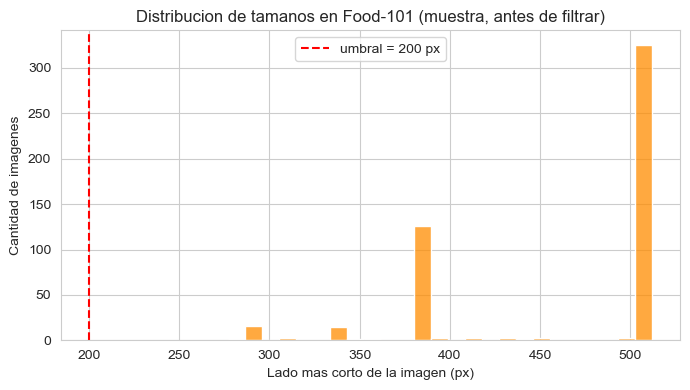

~0.0% de la muestra tiene el lado mas corto por debajo de 200 px


In [9]:
# Distribucion de tamanos en una muestra, ANTES de filtrar
muestra_tam = random.sample(rutas_train_raw, 500)
lados_cortos = []
for ruta, _ in muestra_tam:
    with Image.open(ruta) as img:
        lados_cortos.append(min(img.size))

plt.figure(figsize=(7, 4))
sns.histplot(lados_cortos, bins=25, color="darkorange")
plt.axvline(200, color="red", linestyle="--", label="umbral = 200 px")
plt.xlabel("Lado mas corto de la imagen (px)")
plt.ylabel("Cantidad de imagenes")
plt.title("Distribucion de tamanos en Food-101 (muestra, antes de filtrar)")
plt.legend()
plt.tight_layout()
plt.show()

pct_bajo_umbral = np.mean(np.array(lados_cortos) < 200) * 100
print(f"~{pct_bajo_umbral:.1f}% de la muestra tiene el lado mas corto por debajo de 200 px")


In [10]:
def filtrar_por_tamano(rutas_etiquetas, tamano_minimo=200, max_por_clase=None, semilla=42):
    '''Filtra por tamano minimo y, opcionalmente, limita la cantidad de imagenes por clase.'''
    rng = random.Random(semilla)
    rutas_barajadas = rutas_etiquetas[:]
    rng.shuffle(rutas_barajadas)  # para no quedarnos siempre con las mismas al limitar por clase

    contador = Counter()
    validas, descartadas = [], 0
    for ruta, clase in rutas_barajadas:
        if max_por_clase is not None and contador[clase] >= max_por_clase:
            continue
        try:
            with Image.open(ruta) as img:
                w, h = img.size
        except Exception:
            descartadas += 1
            continue
        if min(w, h) >= tamano_minimo:
            validas.append((ruta, clase))
            contador[clase] += 1
        else:
            descartadas += 1
    return validas, descartadas


inicio = time.time()
rutas_train, descartadas_train = filtrar_por_tamano(
    rutas_train_raw, tamano_minimo=TAMANO_MINIMO_FUENTE, max_por_clase=MAX_POR_CLASE)
rutas_test, descartadas_test = filtrar_por_tamano(
    rutas_test_raw, tamano_minimo=TAMANO_MINIMO_FUENTE, max_por_clase=MAX_POR_CLASE)
print(f"Filtrado completado en {time.time()-inicio:.1f} s")

print(f"Entrenamiento -> validas: {len(rutas_train)}, descartadas por tamano/limite: {descartadas_train}")
print(f"Test           -> validas: {len(rutas_test)}, descartadas por tamano/limite: {descartadas_test}")


Filtrado completado en 58.1 s
Entrenamiento -> validas: 50500, descartadas por tamano/limite: 5
Test           -> validas: 25250, descartadas por tamano/limite: 0


### 2.1 Imágenes por clase y balanceo

Food-101 es, por diseño oficial, casi perfectamente balanceado (750 imágenes de entrenamiento y 250 de test por clase). Sin embargo, **nuestro propio filtrado por tamaño (> 200 px) puede afectar a algunas clases más que a otras** — algunas categorías de comida podrían tener, en promedio, fotos con proporciones más alargadas y perder más imágenes en el filtro. Por eso conviene verificarlo explícitamente después de filtrar, en vez de asumir que sigue balanceado.

Se calcula la cantidad de imágenes por clase, y si la relación entre la clase con más y la clase con menos imágenes supera un umbral (`UMBRAL_DESBALANCE`), se aplica **submuestreo automático**: todas las clases se recortan al tamaño de la clase más chica, reutilizando la misma función `filtrar_por_tamano` con su parámetro `max_por_clase`. Esto garantiza un dataset de entrenamiento perfectamente balanceado, al costo de descartar algunas imágenes de las clases más grandes.

> Nota: el balanceo se aplica solo al conjunto de **entrenamiento**. El conjunto de **test** se deja con todas las imágenes válidas disponibles, para evaluar el modelo sobre la mayor cantidad de datos reales posible — un test set moderadamente desbalanceado no sesga el aprendizaje del modelo, así que forzar su balanceo solo tiraría datos de evaluación sin necesidad.


In [11]:
conteo_train = Counter(c for _, c in rutas_train)
conteo_test = Counter(c for _, c in rutas_test)

tabla_conteo = pd.DataFrame([
    {"Clase": c, "Imagenes train": conteo_train.get(c, 0), "Imagenes test": conteo_test.get(c, 0)}
    for c in CLASES
]).sort_values("Imagenes train").reset_index(drop=True)

print(tabla_conteo.describe()[["Imagenes train", "Imagenes test"]])
tabla_conteo


       Imagenes train  Imagenes test
count           101.0          101.0
mean            500.0          250.0
std               0.0            0.0
min             500.0          250.0
25%             500.0          250.0
50%             500.0          250.0
75%             500.0          250.0
max             500.0          250.0


,Clase,Imagenes train,Imagenes test
0,apple_pie,500,250
1,baby_back_ribs,500,250
2,baklava,500,250
3,beef_carpaccio,500,250
4,beef_tartare,500,250
...,...,...,...
96,tacos,500,250
97,takoyaki,500,250
98,tiramisu,500,250
99,tuna_tartare,500,250


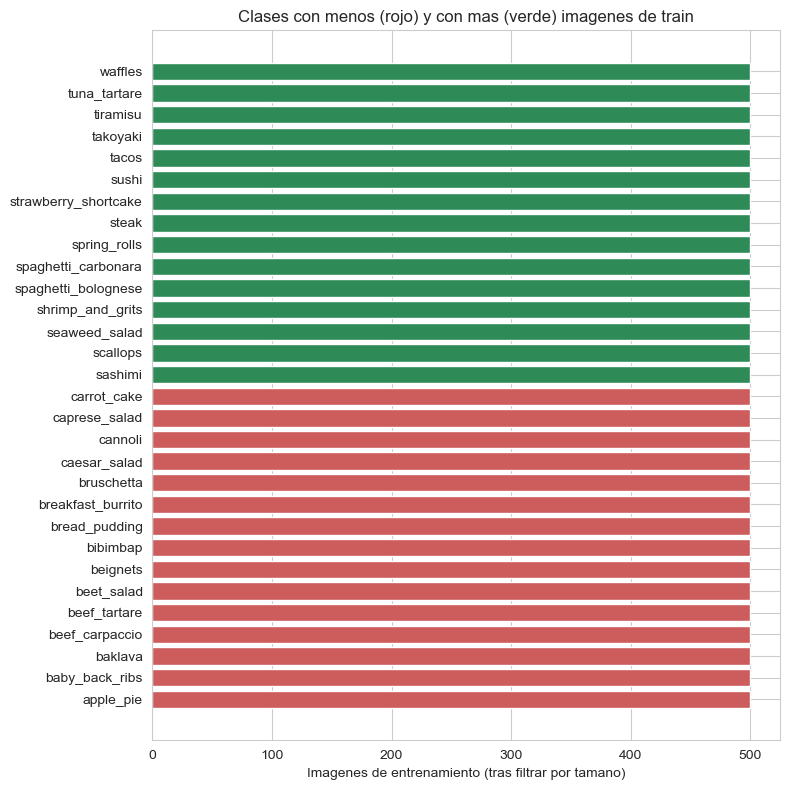

In [12]:
# Visualizacion: las 15 clases con menos y con mas imagenes de entrenamiento tras el filtrado
extremos = pd.concat([tabla_conteo.head(15), tabla_conteo.tail(15)])
plt.figure(figsize=(8, 8))
colores = ["indianred"] * 15 + ["seagreen"] * 15
plt.barh(extremos["Clase"], extremos["Imagenes train"], color=colores)
plt.xlabel("Imagenes de entrenamiento (tras filtrar por tamano)")
plt.title("Clases con menos (rojo) y con mas (verde) imagenes de train")
plt.tight_layout()
plt.show()


In [13]:
UMBRAL_DESBALANCE = 1.2  # si la clase mas grande tiene 20% mas imagenes que la mas chica, se balancea

minimo_train = int(tabla_conteo["Imagenes train"].min())
maximo_train = int(tabla_conteo["Imagenes train"].max())
ratio_train = maximo_train / minimo_train if minimo_train > 0 else float("inf")
print(f"Train -> minimo: {minimo_train}, maximo: {maximo_train}, relacion maximo/minimo: {ratio_train:.2f}")

if ratio_train > UMBRAL_DESBALANCE:
    print(f"Desbalance detectado (relacion {ratio_train:.2f} > {UMBRAL_DESBALANCE}). "
          f"Aplicando submuestreo: se recorta cada clase a {minimo_train} imagenes.")
    rutas_train, _ = filtrar_por_tamano(
        rutas_train_raw, tamano_minimo=TAMANO_MINIMO_FUENTE, max_por_clase=minimo_train)
else:
    print(f"Sin desbalance relevante (relacion {ratio_train:.2f} <= {UMBRAL_DESBALANCE}). "
          f"No se modifica el conjunto de entrenamiento.")

conteo_train_final = Counter(c for _, c in rutas_train)
print(f"Imagenes de entrenamiento tras el balanceo: {len(rutas_train)} "
      f"({min(conteo_train_final.values())} a {max(conteo_train_final.values())} por clase)")


Train -> minimo: 500, maximo: 500, relacion maximo/minimo: 1.00
Sin desbalance relevante (relacion 1.00 <= 1.2). No se modifica el conjunto de entrenamiento.
Imagenes de entrenamiento tras el balanceo: 50500 (500 a 500 por clase)


## 3. Muestra visual del dataset

Una imagen de ejemplo para una selección de clases, ya filtradas por tamaño.


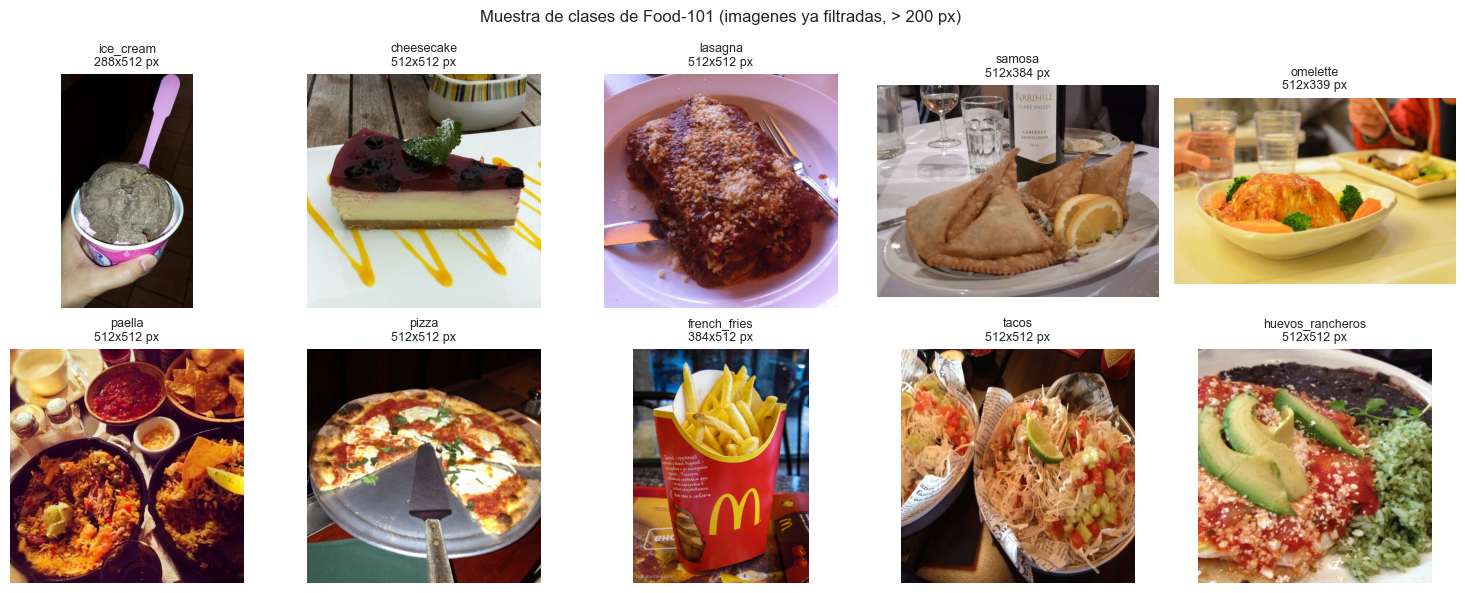

In [14]:
clases_muestra = random.sample(CLASES, 10)
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for ax, clase in zip(axes.flat, clases_muestra):
    ruta_ejemplo = next(r for r, c in rutas_train if c == clase)
    img = Image.open(ruta_ejemplo)
    ax.imshow(img)
    ax.set_title(f"{clase}\n{img.size[0]}x{img.size[1]} px", fontsize=9)
    ax.axis("off")
plt.suptitle("Muestra de clases de Food-101 (imagenes ya filtradas, > 200 px)")
plt.tight_layout()
plt.show()


## 4. Preprocesamiento y aumento de datos (data augmentation)

Como la CNN se entrena **desde cero** (no partimos de pesos preentrenados), el modelo es más propenso a sobreajustarse, sobre todo trabajando con un subconjunto de datos. Para mitigarlo, además de Dropout y weight decay (ver sección 5), se aplica **aumento de datos** solo al conjunto de entrenamiento:

- `RandomResizedCrop`: recorta una región aleatoria de la imagen y la reescala — simula variaciones de encuadre y distancia.
- `RandomHorizontalFlip`: espeja la imagen horizontalmente — un plato de comida se reconoce igual reflejado.
- `RandomRotation`: pequeñas rotaciones — la cámara no siempre está perfectamente nivelada.
- `ColorJitter`: variaciones aleatorias de brillo/contraste/saturación — la iluminación real varía mucho entre fotos.

El conjunto de **test nunca se aumenta**: solo se redimensiona y se normaliza, para evaluar siempre sobre la misma versión "limpia" de cada imagen.

La normalización usa las estadísticas de ImageNet (`mean`/`std` por canal), un estándar habitual incluso quando se entrena desde cero, porque mantiene los valores de entrada en un rango numérico estable para la red.


In [15]:
transform_train = T.Compose([
    T.RandomResizedCrop(TAMANO_IMAGEN, scale=(0.7, 1.0)),
    T.RandomHorizontalFlip(),
    T.RandomRotation(15),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

transform_test = T.Compose([
    T.Resize((TAMANO_IMAGEN, TAMANO_IMAGEN)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


## 5. Diseño orientado a objetos: las clases del proyecto

| Clase | Responsabilidad |
|---|---|
| `FoodDataset` | Carga las imágenes filtradas y aplica las transformaciones; hereda de `torch.utils.data.Dataset`. |
| `CNNClasificador` | La arquitectura de la red convolucional; hereda de `torch.nn.Module`. |
| `EntrenadorCNN` | Ciclo de entrenamiento/validación, historial de métricas y guardado del mejor modelo. |
| `EvaluadorModelo` | Predicciones, accuracy top-1/top-5, reporte de clasificación y análisis de errores. |


In [16]:
class FoodDataset(Dataset):
    '''Dataset personalizado para Food-101 a partir de una lista (ruta, nombre_clase) ya filtrada.'''

    def __init__(self, rutas_etiquetas, clase_a_idx, transform=None):
        self.rutas_etiquetas = rutas_etiquetas
        self.clase_a_idx = clase_a_idx
        self.transform = transform

    def __len__(self):
        return len(self.rutas_etiquetas)

    def __getitem__(self, idx):
        ruta, clase = self.rutas_etiquetas[idx]
        imagen = Image.open(ruta).convert("RGB")
        if self.transform is not None:
            imagen = self.transform(imagen)
        return imagen, self.clase_a_idx[clase]


### Diseño de la arquitectura CNN

La red sigue el patrón clásico de "bloques convolucionales + clasificador":

- **4 bloques convolucionales**, cada uno con `Conv2d -> BatchNorm2d -> ReLU -> MaxPool2d`. Los canales crecen progresivamente (32 → 64 → 128 → 256): las primeras capas detectan patrones simples (bordes, colores) con pocos filtros; las capas profundas combinan esos patrones en texturas y formas más complejas, por lo que necesitan más filtros. Cada `MaxPool2d` reduce a la mitad el alto y el ancho, así que la información espacial se va "comprimiendo" mientras la información de patrones (canales) aumenta.
- **BatchNorm2d** después de cada convolución: estabiliza y acelera el entrenamiento normalizando las activaciones de cada mini-lote; también actúa como una forma leve de regularización.
- **`AdaptiveAvgPool2d(1)`** en vez de aplanar directamente: promedia cada mapa de características a un solo valor, sin importar el tamaño espacial que haya quedado. Esto hace que la arquitectura no dependa de un `TAMANO_IMAGEN` fijo y reduce drásticamente la cantidad de parámetros frente a aplanar todo el mapa de activaciones.
- **Cabezal clasificador**: `Dropout -> Linear -> ReLU -> Dropout -> Linear(→101)`, con Dropout para reducir sobreajuste, igual que en el cuadernillo de Imagenette.


In [17]:
class CNNClasificador(nn.Module):
    '''CNN convolucional simple: 4 bloques Conv-BN-ReLU-MaxPool + cabezal totalmente conectado.'''

    def __init__(self, n_clases, canales_entrada=3, dropout=0.4):
        super().__init__()

        def bloque_conv(c_in, c_out):
            return nn.Sequential(
                nn.Conv2d(c_in, c_out, kernel_size=3, padding=1),
                nn.BatchNorm2d(c_out),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
            )

        self.extractor = nn.Sequential(
            bloque_conv(canales_entrada, 32),
            bloque_conv(32, 64),
            bloque_conv(64, 128),
            bloque_conv(128, 256),
        )
        self.pool_global = nn.AdaptiveAvgPool2d(1)
        self.clasificador = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(256, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(256, n_clases),
        )

    def forward(self, x):
        x = self.extractor(x)
        x = self.pool_global(x)
        return self.clasificador(x)


# Verificacion rapida de las dimensiones
modelo_prueba = CNNClasificador(n_clases=N_CLASES)
salida_prueba = modelo_prueba(torch.randn(2, 3, TAMANO_IMAGEN, TAMANO_IMAGEN))
n_parametros = sum(p.numel() for p in modelo_prueba.parameters())
print("Forma de salida:", salida_prueba.shape)
print(f"Parametros entrenables: {n_parametros:,}")
del modelo_prueba, salida_prueba


Forma de salida: torch.Size([2, 101])
Parametros entrenables: 481,125


In [ ]:
def top_k_accuracy(salidas, etiquetas, k=5):
    '''Proporcion de muestras donde la etiqueta real esta entre las k predicciones con mayor puntaje.'''
    k = min(k, salidas.shape[1])
    topk_idx = salidas.topk(k, dim=1).indices
    aciertos = topk_idx.eq(etiquetas.unsqueeze(1)).any(dim=1)
    return aciertos.float().mean().item()


class EntrenadorCNN:
    '''Ciclo de entrenamiento/validacion, historial de metricas y guardado del mejor modelo.'''

    def __init__(self, modelo, dispositivo="cuda", lr=1e-3, weight_decay=1e-4):
        self.modelo = modelo.to(dispositivo)
        self.dispositivo = dispositivo
        self.optimizador = torch.optim.Adam(self.modelo.parameters(), lr=lr, weight_decay=weight_decay)
        self.criterio = nn.CrossEntropyLoss()
        self.historial = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "val_top5": []}
        self.mejor_val_acc = 0.0
        self.mejores_pesos = None

    def _paso_epoca(self, loader, entrenar):
        self.modelo.train() if entrenar else self.modelo.eval()
        perdida_total, correctos, top5_correctos, total = 0.0, 0, 0.0, 0
        contexto = torch.enable_grad() if entrenar else torch.no_grad()
        with contexto:
            for X_batch, y_batch in loader:
                X_batch = X_batch.to(self.dispositivo)
                y_batch = y_batch.to(self.dispositivo)
                if entrenar:
                    self.optimizador.zero_grad()
                salidas = self.modelo(X_batch)
                perdida = self.criterio(salidas, y_batch)
                if entrenar:
                    perdida.backward()
                    self.optimizador.step()
                perdida_total += perdida.item() * X_batch.size(0)
                correctos += (salidas.argmax(1) == y_batch).sum().item()
                top5_correctos += top_k_accuracy(salidas, y_batch, k=5) * X_batch.size(0)
                total += X_batch.size(0)
        return perdida_total / total, correctos / total, top5_correctos / total

    def entrenar(self, train_loader, val_loader, epocas=15, verbose=True):
        for epoca in range(1, epocas + 1):
            train_loss, train_acc, _ = self._paso_epoca(train_loader, entrenar=True)
            val_loss, val_acc, val_top5 = self._paso_epoca(val_loader, entrenar=False)

            self.historial["train_loss"].append(train_loss)
            self.historial["train_acc"].append(train_acc)
            self.historial["val_loss"].append(val_loss)
            self.historial["val_acc"].append(val_acc)
            self.historial["val_top5"].append(val_top5)

            if val_acc > self.mejor_val_acc:
                self.mejor_val_acc = val_acc
                self.mejores_pesos = {k: v.clone() for k, v in self.modelo.state_dict().items()}

            if verbose:
                print(f"Epoca {epoca:>3}/{epocas} | "
                      f"train_loss={train_loss:.4f} train_acc={train_acc:.3f} | "
                      f"val_loss={val_loss:.4f} val_acc={val_acc:.3f} val_top5={val_top5:.3f}")
        return self.historial

    def restaurar_mejor_modelo(self):
        '''Carga en el modelo los pesos de la epoca con mejor accuracy de validacion.'''
        if self.mejores_pesos is not None:
            self.modelo.load_state_dict(self.mejores_pesos)

    def graficar_curvas(self):
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        axes[0].plot(self.historial["train_loss"], label="entrenamiento")
        axes[0].plot(self.historial["val_loss"], label="validacion")
        axes[0].set_title("Perdida"); axes[0].set_xlabel("Epoca"); axes[0].legend()

        axes[1].plot(self.historial["train_acc"], label="entrenamiento")
        axes[1].plot(self.historial["val_acc"], label="validacion")
        axes[1].set_title("Accuracy (top-1)"); axes[1].set_xlabel("Epoca"); axes[1].legend()

        axes[2].plot(self.historial["val_top5"], label="validacion", color="green")
        axes[2].set_title("Accuracy top-5 (validacion)"); axes[2].set_xlabel("Epoca"); axes[2].legend()
        plt.tight_layout()
        plt.show()


In [19]:
class EvaluadorModelo:
    '''Predicciones, metricas top-1/top-5, reporte de clasificacion y analisis de errores.'''

    def __init__(self, modelo, dispositivo="cpu"):
        self.modelo = modelo
        self.dispositivo = dispositivo

    def predecir(self, loader):
        self.modelo.eval()
        preds, reales, top5_aciertos = [], [], []
        with torch.no_grad():
            for X_batch, y_batch in loader:
                X_batch = X_batch.to(self.dispositivo)
                salidas = self.modelo(X_batch)
                preds.extend(salidas.argmax(1).cpu().numpy())
                reales.extend(y_batch.numpy())
                top5_aciertos.append(top_k_accuracy(salidas.cpu(), y_batch, k=5) * X_batch.size(0))
        return np.array(reales), np.array(preds), sum(top5_aciertos) / len(reales)

    def reporte(self, loader, nombres_clases):
        reales, preds, top5_acc = self.predecir(loader)
        acc = accuracy_score(reales, preds)
        print(f"Accuracy (top-1): {acc:.3f}")
        print(f"Accuracy (top-5): {top5_acc:.3f}")
        print()
        print(classification_report(reales, preds, target_names=nombres_clases, zero_division=0))
        return reales, preds, acc, top5_acc

    def accuracy_por_clase(self, reales, preds, nombres_clases, top_n=10):
        '''Devuelve un DataFrame con la accuracy (recall) de cada clase, y grafica las top_n mejores/peores.'''
        cm = confusion_matrix(reales, preds, labels=range(len(nombres_clases)))
        with np.errstate(divide="ignore", invalid="ignore"):
            acc_clase = np.divide(cm.diagonal(), cm.sum(axis=1), out=np.zeros(len(nombres_clases)), where=cm.sum(axis=1) != 0)
        df = pd.DataFrame({"Clase": nombres_clases, "Accuracy": acc_clase}).sort_values("Accuracy")

        peores = df.head(top_n)
        mejores = df.tail(top_n)
        combinado = pd.concat([peores, mejores])

        plt.figure(figsize=(8, 8))
        colores = ["indianred"] * len(peores) + ["seagreen"] * len(mejores)
        plt.barh(combinado["Clase"], combinado["Accuracy"], color=colores)
        plt.xlabel("Accuracy por clase (recall)")
        plt.title(f"Las {top_n} clases mas dificiles y las {top_n} mas faciles")
        plt.tight_layout()
        plt.show()
        return df

    def pares_mas_confundidos(self, reales, preds, nombres_clases, top_n=15):
        '''Tabla con los pares (clase real, clase predicha) que mas veces se confundieron entre si.'''
        cm = confusion_matrix(reales, preds, labels=range(len(nombres_clases)))
        np.fill_diagonal(cm, 0)
        indices = np.dstack(np.unravel_index(np.argsort(-cm, axis=None), cm.shape))[0]
        filas = []
        for i, j in indices:
            if cm[i, j] == 0:
                break
            filas.append({"Clase real": nombres_clases[i], "Predicha como": nombres_clases[j], "Veces": int(cm[i, j])})
            if len(filas) >= top_n:
                break
        return pd.DataFrame(filas)

    def graficar_matriz_confusion(self, reales, preds, nombres_clases, normalizar=True, mostrar_valores=None):
        '''
        Genera y grafica la matriz de confusion completa.

        - normalizar=True: cada fila se expresa como proporcion (accuracy/recall por clase)
          en vez de conteos crudos. Con muchas clases esto es mas legible, porque las clases
          con mas imagenes de test no "dominan" visualmente el mapa de calor.
        - mostrar_valores: si es None, se decide automaticamente segun la cantidad de clases
          (con pocas clases, ej. 10, se muestran los numeros en cada celda; con muchas,
          ej. 101, se ocultan para no saturar la imagen y se deja solo el color).
        '''
        n_clases = len(nombres_clases)
        cm = confusion_matrix(reales, preds, labels=range(n_clases))

        if normalizar:
            with np.errstate(divide="ignore", invalid="ignore"):
                cm_mostrar = cm.astype(float) / cm.sum(axis=1, keepdims=True)
                cm_mostrar = np.nan_to_num(cm_mostrar)
            fmt, etiqueta_barra = ".2f", "Proporcion (recall por clase)"
        else:
            cm_mostrar, fmt, etiqueta_barra = cm, "d", "Cantidad de imagenes"

        if mostrar_valores is None:
            mostrar_valores = n_clases <= 20  # con mas clases, el texto se vuelve ilegible

        lado = max(8, n_clases * 0.35)
        plt.figure(figsize=(lado, lado))
        sns.heatmap(cm_mostrar, annot=mostrar_valores, fmt=fmt, cmap="Blues",
                    xticklabels=nombres_clases, yticklabels=nombres_clases,
                    cbar_kws={"label": etiqueta_barra}, square=True)
        plt.xlabel("Clase predicha")
        plt.ylabel("Clase real")
        plt.title(f"Matriz de confusion ({n_clases} clases)")
        plt.xticks(rotation=90, fontsize=max(4, min(10, 220 // n_clases)))
        plt.yticks(rotation=0, fontsize=max(4, min(10, 220 // n_clases)))
        plt.tight_layout()
        plt.show()
        return cm


## 6. Preparación de los datos y DataLoaders

Se construyen los `FoodDataset` (entrenamiento con aumento de datos, test sin aumento) y los `DataLoader` correspondientes.


In [20]:
ds_train = FoodDataset(rutas_train, CLASE_A_IDX, transform=transform_train)
ds_test = FoodDataset(rutas_test, CLASE_A_IDX, transform=transform_test)

print("Imagenes de entrenamiento:", len(ds_train))
print("Imagenes de test:          ", len(ds_test))

train_loader = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = DataLoader(ds_test, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)


Imagenes de entrenamiento: 50500
Imagenes de test:           25250


## 7. Entrenamiento del modelo

Se entrena `CNNClasificador` desde cero. Dado que se trabaja con un subconjunto de datos y relativamente pocas épocas por motivos de tiempo de cómputo, **no se espera alcanzar el estado del arte** de Food-101 (que ronda 90%+ con modelos grandes, todos los datos y muchas más épocas). El objetivo de este cuadernillo es demostrar correctamente el pipeline completo: diseño de la arquitectura, entrenamiento y evaluación.


Epoca   1/20 | train_loss=4.3533 train_acc=0.044 | val_loss=4.1224 val_acc=0.071 val_top5=0.227
Epoca   2/20 | train_loss=4.0502 train_acc=0.081 | val_loss=3.8050 val_acc=0.114 val_top5=0.321
Epoca   3/20 | train_loss=3.8802 train_acc=0.108 | val_loss=3.6437 val_acc=0.139 val_top5=0.363
Epoca   4/20 | train_loss=3.7598 train_acc=0.123 | val_loss=3.5514 val_acc=0.154 val_top5=0.397
Epoca   5/20 | train_loss=3.6583 train_acc=0.144 | val_loss=3.4240 val_acc=0.178 val_top5=0.432
Epoca   6/20 | train_loss=3.5704 train_acc=0.158 | val_loss=3.4128 val_acc=0.184 val_top5=0.434
Epoca   7/20 | train_loss=3.4845 train_acc=0.171 | val_loss=3.2299 val_acc=0.215 val_top5=0.494
Epoca   8/20 | train_loss=3.3991 train_acc=0.191 | val_loss=2.9927 val_acc=0.257 val_top5=0.557
Epoca   9/20 | train_loss=3.3331 train_acc=0.203 | val_loss=2.9919 val_acc=0.266 val_top5=0.558
Epoca  10/20 | train_loss=3.2619 train_acc=0.216 | val_loss=2.8850 val_acc=0.284 val_top5=0.585
Epoca  11/20 | train_loss=3.2168 train_a

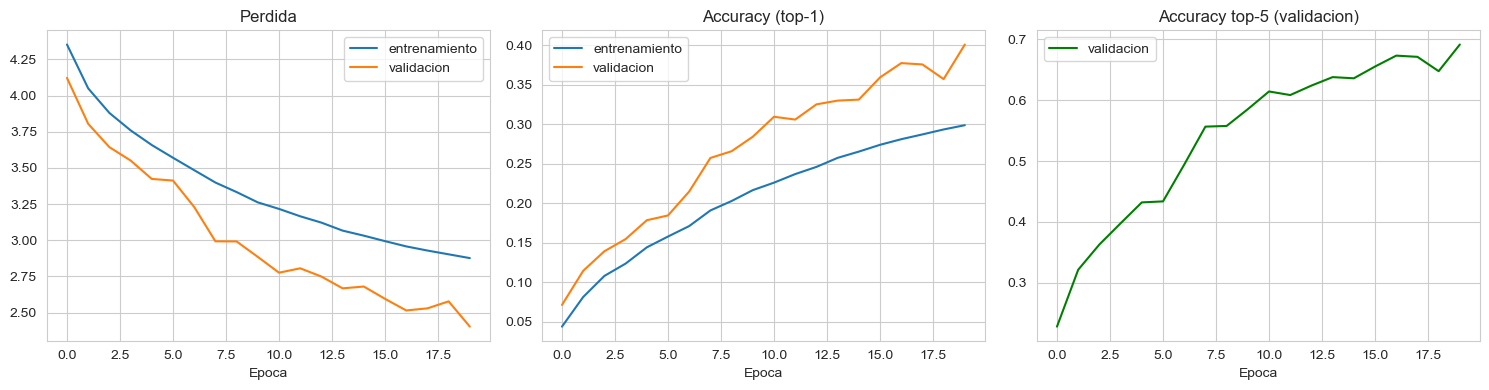

In [21]:
modelo = CNNClasificador(n_clases=N_CLASES, dropout=0.4)
entrenador = EntrenadorCNN(modelo, dispositivo=DISPOSITIVO, lr=1e-3, weight_decay=1e-4)

inicio = time.time()
historial = entrenador.entrenar(train_loader, test_loader, epocas=EPOCAS)
print(f"Entrenamiento completado en {(time.time()-inicio)/60:.1f} min")
print(f"Mejor accuracy de validacion durante el entrenamiento: {entrenador.mejor_val_acc:.3f}")

entrenador.restaurar_mejor_modelo()   # nos quedamos con los pesos de la mejor epoca, no necesariamente la ultima
entrenador.graficar_curvas()


## 8. Evaluación del modelo

Se usan **dos métricas principales**, ambas estándar en la literatura de Food-101:

- **Accuracy top-1**: porcentaje de veces que la predicción con mayor puntaje coincide con la clase real.
- **Accuracy top-5**: porcentaje de veces que la clase real está entre las 5 predicciones más probables del modelo. Es especialmente relevante en Food-101 porque muchas categorías son visualmente muy parecidas entre sí (por ejemplo, distintos tipos de sopa o de carne), y top-5 refleja mejor si el modelo "entendió" la imagen aunque no haya acertado la clase exacta.

También se analiza en qué clases falla más el modelo y qué pares de clases confunde con más frecuencia — un análisis de errores más útil que una matriz de confusión de 101×101, imposible de leer.


In [22]:
evaluador = EvaluadorModelo(modelo, dispositivo=DISPOSITIVO)
reales, preds, acc, top5_acc = evaluador.reporte(test_loader, CLASES)


Accuracy (top-1): 0.401
Accuracy (top-5): 0.692

                         precision    recall  f1-score   support

              apple_pie       0.30      0.07      0.12       250
         baby_back_ribs       0.26      0.65      0.37       250
                baklava       0.63      0.26      0.37       250
         beef_carpaccio       0.44      0.62      0.52       250
           beef_tartare       0.28      0.53      0.36       250
             beet_salad       0.50      0.24      0.32       250
               beignets       0.68      0.67      0.68       250
               bibimbap       0.38      0.70      0.49       250
          bread_pudding       0.21      0.04      0.07       250
      breakfast_burrito       0.18      0.07      0.10       250
             bruschetta       0.37      0.31      0.34       250
           caesar_salad       0.53      0.55      0.54       250
                cannoli       0.62      0.18      0.28       250
          caprese_salad       0.42      

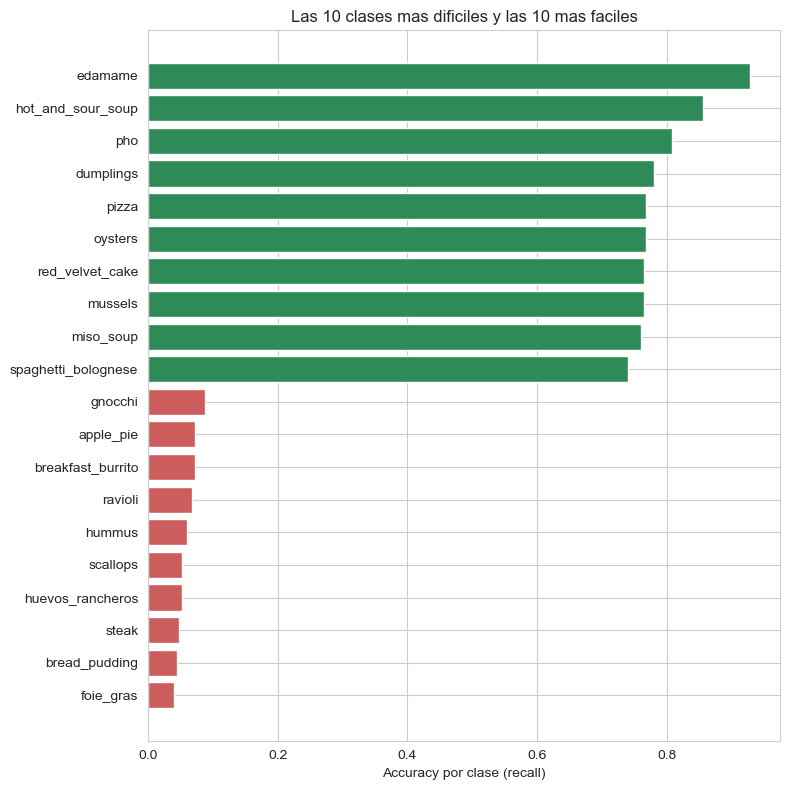

In [23]:
tabla_accuracy_clase = evaluador.accuracy_por_clase(reales, preds, CLASES, top_n=10)


In [24]:
tabla_confusiones = evaluador.pares_mas_confundidos(reales, preds, CLASES, top_n=15)
tabla_confusiones


,Clase real,Predicha como,Veces
0,pad_thai,spaghetti_bolognese,79
1,breakfast_burrito,chicken_quesadilla,70
2,steak,baby_back_ribs,61
3,ravioli,lasagna,50
4,hummus,chicken_quesadilla,45
5,onion_rings,french_fries,44
6,macaroni_and_cheese,french_onion_soup,44
7,panna_cotta,cheesecake,40
8,panna_cotta,strawberry_shortcake,39
9,tuna_tartare,beef_tartare,39


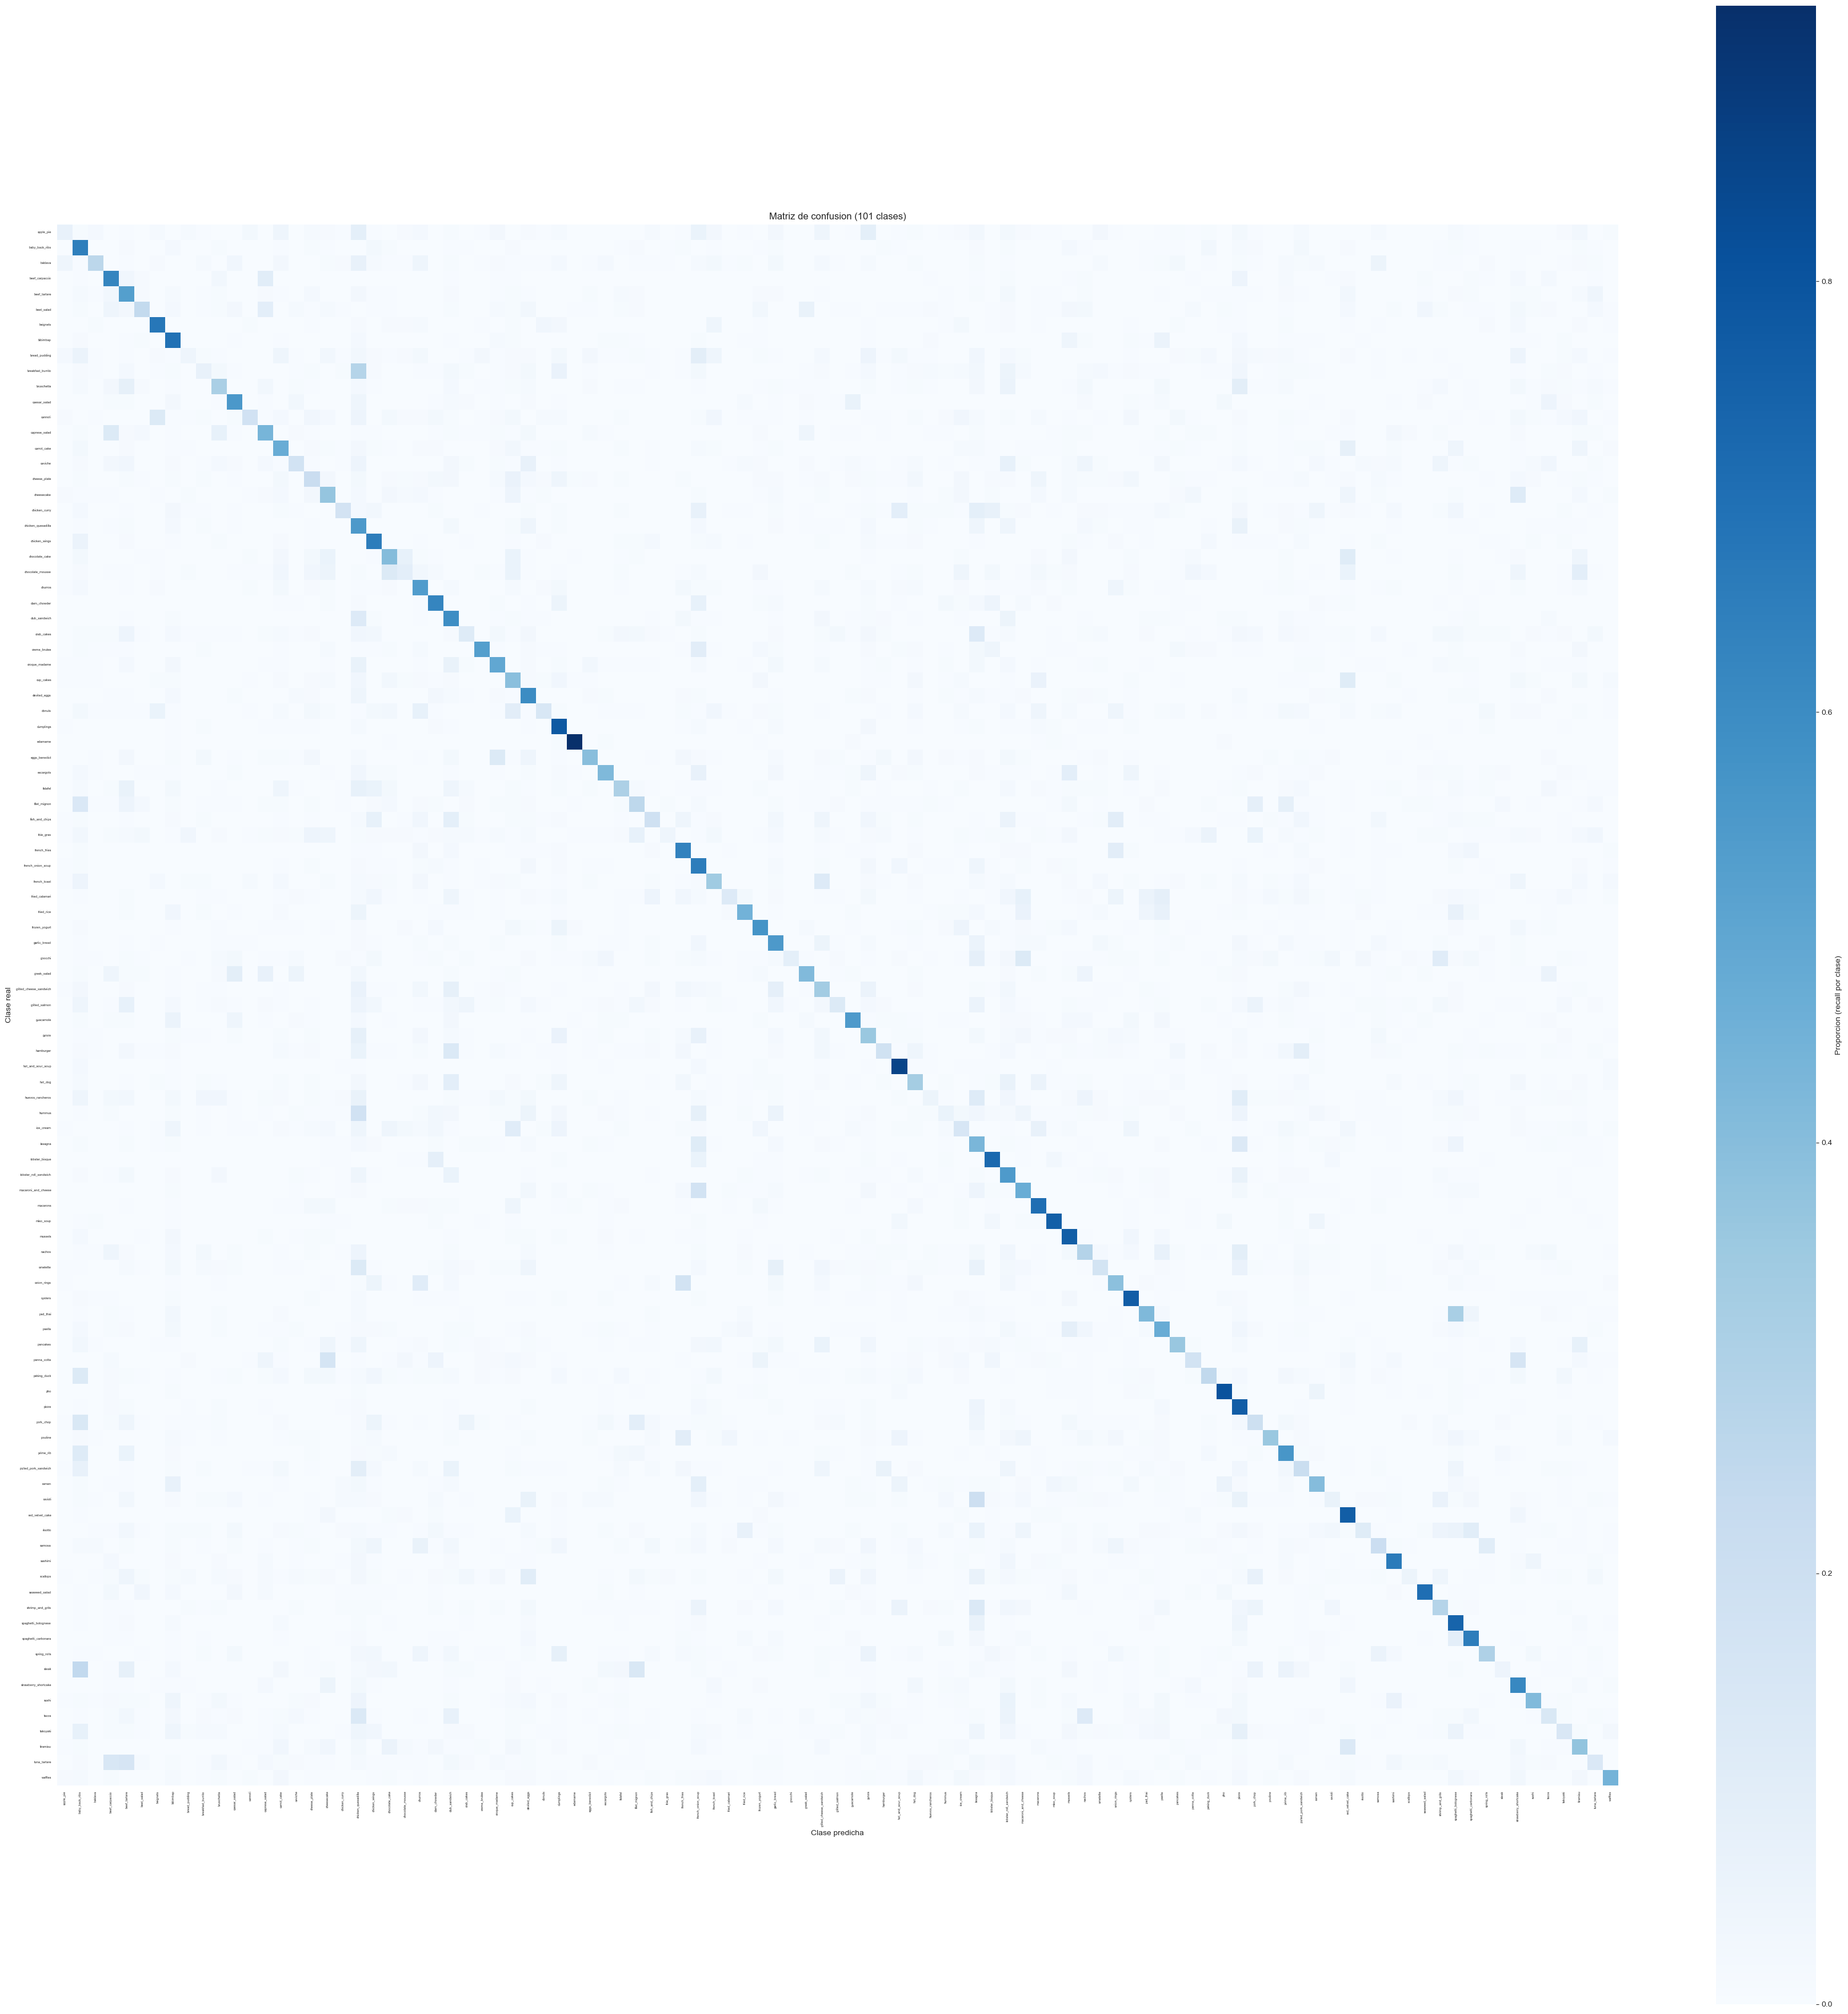

In [25]:
# Matriz de confusion completa (normalizada por fila, sin numeros por celda dado que son 101 clases)
_ = evaluador.graficar_matriz_confusion(reales, preds, CLASES, normalizar=True)


## Conclusiones

- Food-101 no garantiza que todas sus imágenes superen los 200 px de lado corto (a diferencia de Imagenette-320), por lo que el filtrado por tamaño implementado en la sección 2 fue un paso necesario y con efecto real sobre el dataset.
- Tras filtrar, se verificó la cantidad de imágenes por clase y se aplicó un **balanceo automático por submuestreo**: si la relación entre la clase más grande y la más chica superaba el umbral definido, todas las clases de entrenamiento se recortaron al tamaño de la más chica, evitando que el modelo aprenda un sesgo hacia las clases sobrerrepresentadas.
- Se diseñó una CNN propia (4 bloques convolucionales + `AdaptiveAvgPool2d` + cabezal totalmente conectado) entrenada **desde cero**, en lugar de reutilizar una red preentrenada como extractor fijo.
- El sobreajuste se controló combinando **Dropout**, **weight decay (L2)**, **BatchNorm** y, de forma adicional respecto al cuadernillo anterior, **aumento de datos (data augmentation)** — relevante porque entrenar una CNN desde cero sobre un subconjunto de datos es más propenso a memorizar que ajustar solo un clasificador sobre características ya aprendidas.
- Se reportaron accuracy top-1 y top-5, más adecuadas que solo top-1 dado que Food-101 tiene clases visualmente muy similares entre sí; el análisis de pares más confundidos ayuda a entender *en qué se equivoca* el modelo, no solo *cuánto*.
- El `EntrenadorCNN` guarda los pesos de la época con mejor accuracy de validación (`restaurar_mejor_modelo`), evitando quedarnos con un modelo que sobreajustó en las últimas épocas.

**Posibles extensiones:** aumentar `MAX_POR_CLASE` y `EPOCAS` para acercarse más al desempeño reportado en la literatura, usar transfer learning (como en el cuadernillo de Imagenette) para comparar contra esta CNN entrenada desde cero, o añadir *early stopping* automático basado en la pérdida de validación.
